# April 2026 Mech Interp Puzzle: Max of List

by Dan Wilhelm [dan@danwil.com]

Herein we provide solutions for the [Bao Lab](https://baulab.info/)'s [April 2026 puzzle: Max of List](https://puzzles.baulab.info/april-2026.html). See the corresponding [GitHub repo](https://github.com/danwilhelm/max_list_puzzle.git).

Notes:
- We use a custom cross-platform NumPy implementation, shown to be equivalent.
- We focus on showing the max() algorithm main path, rather than edge-cases and EOS production.

---
## Table of Contents

- [Setup code](#setup): Loads helper modules.
- [Sidebar](#sidebar): We provide counterexamples showing that Puzzle 2 is not 100% accurate.
- [Sampling code](#sample): Samples activations from each model.

### [Puzzle 1](#puzzle1)
We introduce three experimental techniques that take advantage of the model's linearity (i.e. absence of layer norms), using them to solve Puzzle 1.

- We show that a single attention head is sufficiently powerful to immediately find the maximum digit.

1. [(1-1)](#1-1) Linearity allows us to independently analyze initial-layer attention scores: `S[E + P] = S[E] + S[P]` (E=embeds, P=positional embeds).
    - Using this, we show how head 3 uses E and P to take the max (and heads 0&2 attend to digits 7-9).
2. [(1-2)](#1-2) We use logistic regression on head residual contributions (after partitioning W_O, for head hi: `W_V[hi] @ W_O[hi]`). By creating a custom per-head unembedding, we determine whether each head's output "knows" the true class.
    - This supports (1-1) by showing head 3 output perfectly "knows" the max digit, while heads 0&2 often know it.
3. [(1-3)](#1-3) We compute attention head logit attributions (by linearity: `W_V[hi] @ W_O[hi] @ W_U.T`).
    - We show that each head either (A) outputs info about the true class`*`, or (B) contributes a surprisingly uniform per-class bias.
    - This supports results from (1-1) and (1-2). It clearly shows that heads 0&2 outputs reinforce head 3 in knowing and promoting only true classes 7-9, which account for >67% of the maxes in all possible sequences.

### [Puzzle 2](#puzzle2)

- [(2-1)](#2-1) We first broadly visualize the below mechanism using a grid of logistic regression results.

Tens digit:
1. [(2-2)](#2-2) Layer 0 Head 1 (L0H1) identifies the max tens digit as in Puzzle 1, copying it to the ANS residual row.
2. [(2-5)](#2-5) Before layer 1, the max tens digit is already known and on the ANS-row residual stream.
    - Using logit attribution, we show that layer 1 heads (A) reinforce this true class (especially heads 1&2) and (B) otherwise provide per-class constants to properly match the unembeddings.

Ones digit:
1. [(2-3)](#2-3) L0H0/2 (heads 0 and 2): Attend to the ANS row, which we know from above contains the tens digit. This info is copied to the ANS+1 residual row.
2. [(2-4)](#2-4) L0H3: Copies each tens digit into the corresponding ones-digit residual activation rows.
3. [(2-6)](#2-6) L1H0/3: Recognize the max ones digit by applying: (A) a score boost when (2-4) matches with (2-3), (B) a score gradient to the ones digits themselves, and (C) a mask on the ones digits via the positional embeds.

### Appendices
1. [(3-1)](#3-1) Ablation experiment results. Interactively supports earlier results and allows viewing of model biases.
2. [(3-2)](#3-2) Attention pattern explorer.

`*` We refer to "output class" as a possible output token, and "true class" as the *correct* token. Further, when we state "copies/contains the tens digit", we mean that some information about the tens digit is copied/contained but using a possibly-different representation, e.g. transformed by W_VO.

---
<a id="setup"></a>
# Setup code

In [1]:
import torch as t
import numpy as np

import plotly_express as px
import matplotlib.pyplot as plt

from attention_only_model import AttentionOnlyModel   # numpy implementation we will use throughout
from helpers import (imshow, attn_logit_means, mean_attn_in, show_logit_contribs,
                     show_attn_gradient, logistic_accuracy, logistic_head_grid)

def where(cond):
    return np.nonzero(cond)[0]

device = "cuda" if t.cuda.is_available() else "mps" if t.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [2]:
# Show that NumPy-based model is equivalent to raw model
from helpers import load_models_04_2026, tokenize_1, tokenize_2, examples_1, examples_2

raw_model_1, raw_model_2, model_1, model_2 = load_models_04_2026(device)

# Verify model implementations the same
toks_1 = np.array([tokenize_1(nums) for nums in examples_1])
toks_2 = np.array([tokenize_2(nums) for nums in examples_2])

results_1, same_logits_1 = model_1.verify_raw_model(toks_1, raw_model_1)
results_2, same_logits_2 = model_2.verify_raw_model(toks_2, raw_model_2, n_iter=2)

assert same_logits_1 and same_logits_2

Downloaded model definition + weights for both models.


---
<a id="sidebar"></a>
## Sidebar: Puzzle 2 Model is not perfectly accurate

To avoid interrupting the mech interp flow, we first show via counterexample that the raw model does not always find the correct max.

This typically occurs with duplicated ones-digits, particularly when they are 0. Experiment with this below!
- **Note:** Running this overwrites any other model_2.run()

In [3]:
counterexample_seqs = [
    [ 0,  0,  4, 57, 63],
    [81,  2, 10,  0,  7],
    [80, 12,  0,  0,  7],
    [45, 44, 44, 31, 23],
    [13, 15, 14, 14, 14],
]

toks = np.array([tokenize_2(seq) for seq in counterexample_seqs])
results, same_logits = model_2.verify_raw_model(toks, raw_model_2, n_iter=2)

if same_logits:
    print(f'The raw and numpy models both incorrectly predict the max:\n')
    for i,seq in enumerate(counterexample_seqs):
        print(f'{i}', seq)
        print(f'\tcorrect answer: {max(seq)}, predictions -'\
              f' raw: {results[0][0][i]}{results[1][0][i]},'
              f' numpy: {results[0][1][i]}{results[1][1][i]}')
else:
    print(f'Logits not same between raw and numpy models.')

The raw and numpy models both incorrectly predict the max:

0 [0, 0, 4, 57, 63]
	correct answer: 63, predictions - raw: 55, numpy: 55
1 [81, 2, 10, 0, 7]
	correct answer: 81, predictions - raw: 99, numpy: 99
2 [80, 12, 0, 0, 7]
	correct answer: 80, predictions - raw: 99, numpy: 99
3 [45, 44, 44, 31, 23]
	correct answer: 45, predictions - raw: 44, numpy: 44
4 [13, 15, 14, 14, 14]
	correct answer: 15, predictions - raw: 11, numpy: 11


---
<a id="sampling"></a>
# Sampling code

We will use several techniques that rely on sampling the activation distributions. We will generate these samples here for clarity.

- In Puzzle 1, we will capture activations for the complete set of 10^5 possible sequences.
- In Puzzle 2, we will also capture a random sample of 10,000.

Note that in both puzzles, the true classes are highly imbalanced toward maxes of 7-9. This may explain why the model overall is biased toward larger maxes (e.g. when multiple heads are ablated in [Appendix 1: Ablation Experiments](#3-1)), and also why additional heads are dedicated to these true classes (as shown in [1-3](#1-3) and [2-5](#2-5)).

In [4]:
# PUZZLE 1: Quickly process and verify all possible 5-digit sequences
# Edit: Colab is very slow so this is ~30 seconds.
from itertools import product

# 10^5 == 100,000 possible sequences (via Cartesian product)
nums_1 = np.array(list(product(range(model_1.num_range), repeat=model_1.list_len)))
y_true_1 = np.max(nums_1, axis=-1)

seqs_1 = np.array([tokenize_1(seq) for seq in nums_1])
logits = model_1.run(seqs_1)
y_pred = np.argmax(logits[:,-1], axis=-1)
assert np.all(y_pred == y_true_1)    # 100% accuracy?

n_per_class_1 = {n: len(where(y_true_1 == n)) for n in range(model_1.num_range)}
print('The true output classes are highly imbalanced:')
print(n_per_class_1)

The true output classes are highly imbalanced:
{0: 1, 1: 31, 2: 211, 3: 781, 4: 2101, 5: 4651, 6: 9031, 7: 15961, 8: 26281, 9: 40951}


In [6]:
# PUZZLE 2: Randomly sample activations from 10,000 sequences
n_examples = 100000

nums_2 = np.random.randint(0, model_2.num_range, size=(n_examples, model_2.list_len))
y_true_2 = np.max(nums_2, axis=-1)

base_seqs_2 = np.array([tokenize_2(seq) for seq in nums_2])
logits_tens = model_2.run(base_seqs_2)
pred_tens = np.argmax(logits_tens[:,-1], axis=-1)

seqs_2 = np.hstack([base_seqs_2, pred_tens[:,None]])
logits_ones = model_2.run(seqs_2)    # note pos=-2 contains the values from tens digit
pred_ones = np.argmax(logits_ones[:,-1], axis=-1)

y_pred = pred_tens*10 + pred_ones
if not np.all(y_pred == y_true_2):
    print('WARNING: The raw model does not properly find the max for:')
    incorrect_ixs = where(y_pred != y_true_2)
    for ix,seq in zip(incorrect_ixs,nums_2[incorrect_ixs]):
        print(f'predicted max: {np.argmax(logits_tens[ix,-1], axis=-1)}{np.argmax(logits_ones[ix,-1], axis=-1)}',
              seq.tolist())

n_per_class_2 = {n: len(where(y_true_2 == n)) for n in range(model_2.num_range)}
print('The true output classes are highly imbalanced:')
print(n_per_class_2)

The true output classes are highly imbalanced:
{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 1, 11: 3, 12: 5, 13: 1, 14: 2, 15: 3, 16: 6, 17: 4, 18: 10, 19: 10, 20: 11, 21: 7, 22: 12, 23: 19, 24: 21, 25: 22, 26: 18, 27: 33, 28: 32, 29: 43, 30: 41, 31: 62, 32: 51, 33: 65, 34: 74, 35: 85, 36: 87, 37: 122, 38: 105, 39: 125, 40: 125, 41: 147, 42: 180, 43: 169, 44: 220, 45: 223, 46: 223, 47: 281, 48: 252, 49: 307, 50: 349, 51: 355, 52: 387, 53: 399, 54: 466, 55: 530, 56: 492, 57: 574, 58: 532, 59: 606, 60: 666, 61: 712, 62: 756, 63: 822, 64: 849, 65: 928, 66: 981, 67: 1037, 68: 1072, 69: 1225, 70: 1232, 71: 1201, 72: 1445, 73: 1476, 74: 1634, 75: 1613, 76: 1785, 77: 1782, 78: 1857, 79: 1888, 80: 2141, 81: 2188, 82: 2321, 83: 2465, 84: 2548, 85: 2657, 86: 2927, 87: 2963, 88: 3026, 89: 3175, 90: 3294, 91: 3418, 92: 3656, 93: 3770, 94: 3976, 95: 4149, 96: 4323, 97: 4584, 98: 4663, 99: 4898}


---
<a id="puzzle1"></a>
# Puzzle 1 - Single-digit Max

Each sequence is of the form: `[ BOS, D0, SEP, D1, SEP, D2, SEP, D3, SEP, D4, ANS, Dmax, EOS ]`.

Our one-layer attention-only no-bias model must predict `EOS` and `Dmax = max(D0, D1, D2, D3, D4)`.

- Each `Di` is a one-digit number 0-9.

## Puzzle 1 Algorithm

We show that a single attention head is sufficiently powerful to immediately find the maximum digit.
- Head 3 masks non-digits using the pos embeds, then assigns an increasing score to increasing embedding digits.
- Head 3 places the max digit on the residual stream, alongside mostly per-class constants from the other heads.
- Heads 0&2 reinforce head 3 in knowing and promoting only true classes 7-9. As we saw when [sampling](#sampling), classes 7-9 are max in >67% of the possible sequences.

To provide evidence toward this, we will:

1. [(1-1)](#1-1) Show how attention head 3 computes max (and how heads 0&2 compute max for classes 7-9).
2. [(1-2)](#1-2) Use logistic regression to esimate how much each head may contribute toward indentifying the true class.
3. [(1-3)](#1-3) Compute the actual per-head logit contributions. We show these are consistent with above, and that each head either contributes (A) per-class constants, or (B) true-class signal.

---
<a id="1-1"></a>
## 1-1. The layer 0 head 3 embedding-scores gradient computes max()

We easily visualize this gradient via linearity, by separately examining the attention scores of embeds S[E] and positional embeds S[P].
- For the layer 0 attention head scores, `S[E+P] = S[E] + S[P]`. This avoids needing to compute every combination of E and P.
- We only must examine the last row scores (ANS), since these are the only contributor to the next-token prediction.

It is also important to understand some properties of softmax:
- Softmax effectively takes the max. So if an input has a somewhat larger score (deeper red in the diagram), it will be primarily attended to.
    - This is why establishing a score gradient selects the max digit!
- Softmax is translation-invariant. So, adding per-row constants do not affect the softmax output:
    - This allows centering by the ANS position in the diagram below (to make particularly large scores stand out as red).
    - Also in the diagram below, note that odd positional embeds (right-side digits Di) add a constant score, while even values (SEP) add a smaller constant score. In effect, this masks for digits while allowing the digit embed gradient (left side) determine the max.

The following heatmap shows the per-head attention scores on each embed (left) and positional embed (right). Each row is equivalent to the LAST row (ANS) of the attention scores. In a single-layer transformer, prior rows do not contribute to the final token prediction so we omit them here.

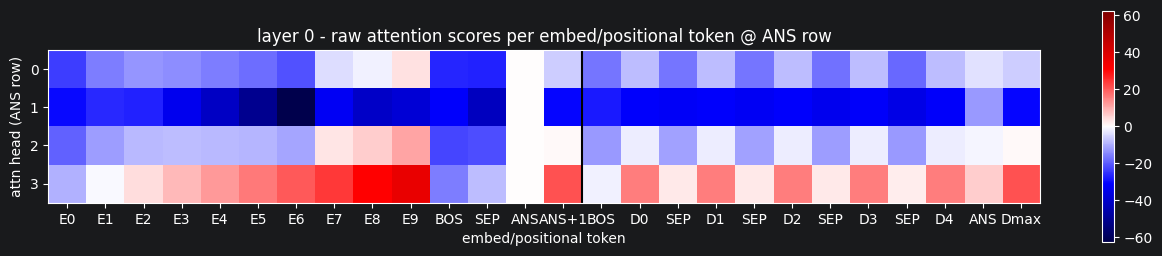

In [7]:
title = f'layer 0 - raw attention scores per embed/positional token @ ANS row'
show_attn_gradient(model_1, layer=0, title=title, ylabel='attn head (ANS row)')   # relative to ANS (white column)

As mentioned, taking softmax of the head 3 ANS row will primarily attend to the largest digit (left). The positional embeds (right) contribute similar constants in digit positions. This will mask for digit scores only and not affect their rank.

Note that heads 0&2 ALSO attend to some embeds E7-E9:
- These heads may have learned to provide additional evidence to support the most common maxes 7-9.

> Side note: Gradients are a common attention motif! For example to pay attention to the next-to-last token, models apply an increasing gradient on the positional embeds while making the last-token score negative, ensuring it isn't selected.

---
<a id="1-2"></a>
## 1-2. How much does each head contribute to the true class?

Let's first train a custom unembedding on each head's residual stream output. This estimates how well each head may correctly identify the true class (or at least whether its output is sensitive to it). We display the accuracy of each unembedding below:

In [8]:
# Let's try to train an unembedding matrix that decodes each head.
layer = 0; head = 3; pos = -1; n_samples = 1000

print('Per-head attn_result logistic regression accuracy')
for head in range(model_1.n_heads):
    X = model_1.attn_result[layer,:,head,pos]     # for head hi: W_V[hi] @ W_O[hi]
    lr, lr_acc = logistic_accuracy(X, y_true_1 % 10, n_samples=n_samples)  # uses logistic regression
    print(f'head {head} accuracy: {lr_acc:.2f}')

print('accuracy if we only correctly guess 7, 8, or 9:',
      (n_per_class_1[7] + n_per_class_1[8] + n_per_class_1[9]) / sum(n_per_class_1.values()))

Per-head attn_result logistic regression accuracy
head 0 accuracy: 0.78
head 1 accuracy: 0.27
head 2 accuracy: 0.78
head 3 accuracy: 1.00
accuracy if we only correctly guess 7, 8, or 9: 0.83193


This aligns well with what may be possible from the attention scores above:
- Head 3 contains perfect info about the true class.
- Heads 0&2 contain substantial info about the true class.
  - Their 78% accuracy is only slightly less than 83% (the baseline if we always correctly guess 7,8,9).
- Head 1 does not attend to the digits much, but it may still bias the output toward common classes.

---
<a id="1-3"></a>
## 1-3. Other heads mostly contribute per-class constants/biases

We will now show that except for head 3 and heads 0&2 (for true-class 7-9), the heads only contribute per-class biases to the output stream. This likely helps the model match the unembedding vectors, given the model lacks bias parameters.

Because the model is linear:
- We can compute (with partitioned W_O) per head hi: `W_V[hi] @ W_O[hi] @ W_U.T` which gives the contribution PER HEAD to the output logits.
- If we sum each of these with the original embeddings, we obtain the output residuals (pre-unembedding).
- As we'll see, heads 0,1,2 all contribute extremely consistent per-class constants to the output stream for classes 0-6.

In the graph below, we show each head's logit contribution per-class (w/ std-dev error bars). Each output class is grouped by true class:
- Similar-height output-class bars indicate outputting a per-class constant (e.g. head 1, which has no knowledge of the true class).
- A true-class bar that differs per-output indicates the head may help distinguish that max digit. (e.g. head 0 class 9, or head 2 classes 7-9)


The conclusions are:
- Head 0 outputs constants, except for true classes 8-9 (and slightly 7?).
- Head 1 only outputs constants.
- Head 2 outputs constants, except for true classes 7-9.
- Head 3 outputs uniquely for all classes.

In [9]:
title = f'Most heads output constant per-class biases/logits. (Note different y-axis scales, and heads 0-2 have no knowledge of true classes <7!)'

means, stds = attn_logit_means(model_1, y_true_1, tens_digit=False)
fig = show_logit_contribs(model_1, means, stds, layer=0, title=title, xaxis_ytrue=False)

These nicely compliment the above experiments, showing that indeed certain heads contribute to particular true-class logits.

- Although the plotted values are means, the standard deviations are very small. So, it likely is an accurate explanation of the overall mechanism (although means would not explain potential edge cases).

In conclusion, we showed how attention computes max in head 3 (and for heads 0&2 for classes 7-9). We then used logistic regression to estimate how much each head may contribute to indentifying the true class. Finally, we showed this was consistent with the actual per-head logit contributions.

---
<a id="puzzle2"></a>
# Puzzle 2 - Two-digit Max

Each sequence is of the form: `[ BOS, T0, D0, SEP, T1, D1, SEP, T2, D2, SEP, T3, D3, SEP, T4, D4, ANS, Tmax, Dmax, EOS ]`.

Our two-layer attention-only no-bias model must predict `EOS` and `Nmax = max(10*T0+D0, 10*T1+D1, 10*T2+D2, 10*T3+D3, 10*T4+D4) = 10*Tmax + Dmax`.

- Each `Ti` and `Di` is a one-digit number 0-9, and each pair interpreted as the two-digit number `Ni = Ti*10 + Di`.

---
## Puzzle 2 Algorithm

**Concisely:** In a similar way to Puzzle 1, the max tens digit is identified in the first layer and its corresponding ones digit is identified in the second layer. In layer 0 it copies each tens digit into its corresponding ones digit activation row. In layer 1 it filters these ones digits only if they match the max ten read from the ANS row, giving them an attention score boost.

> Note that in the first layer, attention can spread information across many activation rows. This often results in (1) redundancy, and (2) multiple paths to correct predictions. These often make simple-looking explanations somewhat but not entirely true. We show this in [Appendix 1: Ablation Experiments](#3-1), which show that single heads with interpretable patterns often are not required for accurate prediction.

Here is a specific breakdown of the mechanism:

- [(2-1)](#2-1) We first broadly visualize the below mechanism using a grid of logistic regression results.

**Tens digit:**
1. [(2-2)](#2-2) Layer 0 Head 1 (L0H1) identifies the max tens digit as in Puzzle 1, copying it to the ANS residual row.
2. [(2-5)](#2-5) Before layer 1, the max tens digit is already known and on the ANS-row residual stream.
    - Using logit attribution, we show that layer 1 heads (A) reinforce this true class (especially heads 1&2) and (B) otherwise provide per-class constants to properly match the unembeddings.

**Ones digit:**
1. [(2-3)](#2-3) L0H0/2 (heads 0 and 2): Attend to the ANS row, which we know from above contains the tens digit. This info is copied to the ANS+1 residual row.
2. [(2-4)](#2-4) L0H3: Copies each tens digit into the corresponding ones-digit residual activation rows.
3. [(2-6)](#2-6) L1H0/3: Recognize the max ones digit by applying: (A) a score boost when (2-4) matches with (2-3), (B) a score gradient to the ones digits themselves, and (C) a mask on the ones digits via the positional embeds.

---
<a id="2-1"></a>
# 2-1. How much is known about the max tens and ones after each attention layer?

Logistic regression presents a nice visual overview of the mechanism, so we'll apply it first. For example, it shows that:
1. The tens digit is always known after layer 0. But between ANS (tens-digit prediction) and ANS+1 (ones-digit prediction), different heads detect it.
    - In ANS+1, L0H0/2 read from the ANS position. However, only both heads combined can perfectly reconstruct it (set `use_attn_out=True`).
2. The tens digit is primarily output by L1H1&2, while the ones digit is output by L1H0&3, a neat segregation.
    - Moreover, logistic regression shows us that the ANS+1 output encodes both the tens AND ones digit!
3. The max ones digit is not known after the first layer (and not ever known in the ANS position).

We should mention a few caveats when interpreting the results:
- Just because a true class _can_ be reconstructed doesn't mean the model uses this knowledge.
- The resulting class directions likely do not correspond to W_U, because 64 dimensions (far more than the 14 output classes) likely allow for numerous reconstruction vectors.
- For this reason, logistic regression vectors are different than W_U, so this DOES NOT CORRESPOND TO THE ACTUAL LOGITS.

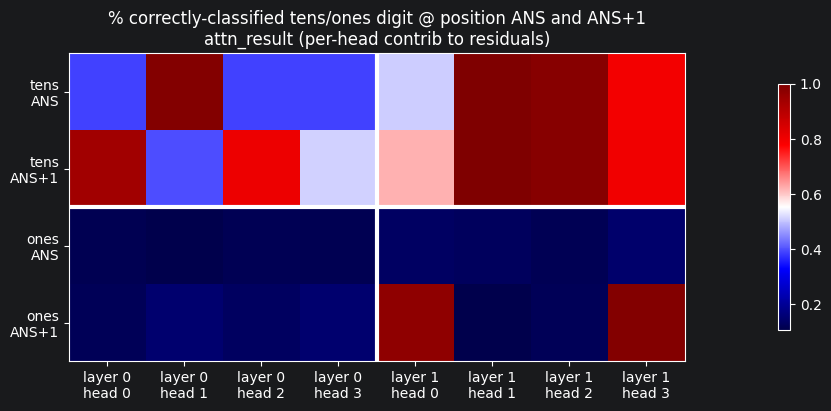

In [10]:
n_samples = 1000

# Try `use_unembed=True` to view per-head logit lens.
# Try `use_attn_out=True` to use the sum of all heads (e.g. shows that L0H0&3 together perfectly reconstruct the tens digit).
probas, head_labels = logistic_head_grid(model_2, y_true_2, n_samples=n_samples,
                                         use_unembed=False, use_attn_out=False)

title = '% correctly-classified tens/ones digit @ position ANS and ANS+1\nattn_result (per-head contrib to residuals)'
fig,axs = imshow(probas.reshape(-1, 4).T, title=title,
                 yticks=['tens\nANS', 'tens\nANS+1', 'ones\nANS', 'ones\nANS+1'],
                 xticks=head_labels, vmin=0.0, vmax=1.0, figsize=(24,4))
axs.axhline(1.5, c='w', linewidth=3); axs.axvline(3.5, c='w', linewidth=3);

Now that we have a general overview of the potential mechanism, let's provide evidence for each piece.

---
<a id="2-2"></a>
## 2-2. How is the max tens digit computed @ ANS?

> "Layer 0 Head 1 (L0H1) identifies the max tens digit as in Puzzle 1, copying it to the ANS residual row."

Layer 0 head 1 in particular attends to the tens digit.
- Recall we can linearize the interactions via `S[E+P] = S[E] + S[P]`.
- As before, we notice an increasing embedding gradient on increasing digits, combined with a pos embed mask on the tens digits (`Ti`).
- Note: You can verify these diagrams by looking at per-example attention patterns. To explore this interactively, see Appendix 2.

Despite this clear gradient, note that many heads may also copy some of the tens.
- For example, ablating head 1 still gives ~16% tens-place accuracy, higher than the 10% random baseline (see Appendix 1).

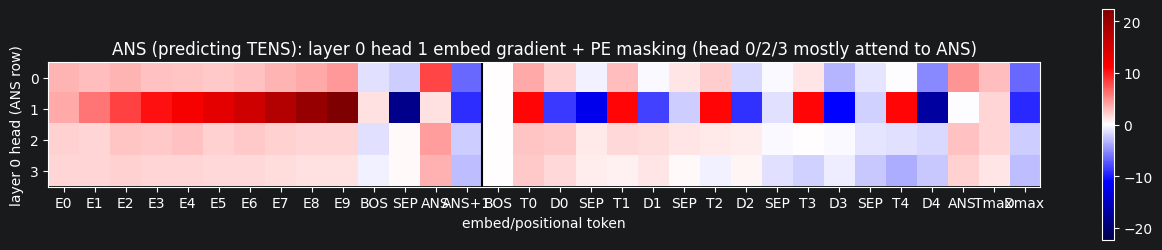

In [11]:
# Note these are raw attention scores, so highest attention probability on LARGEST present.
title = 'ANS (predicting TENS): layer 0 head 1 embed gradient + PE masking (head 0/2/3 mostly attend to ANS)'

# To predict the tens digit, we compute the attn scores row for when the token is ANS at position ANS_POS.
row = model_2.W_E[model_2.ANS] + model_2.W_P[model_2.ANS_POS]
show_attn_gradient(model_2, layer=0, title=title, sub_pos=model_2.ANS+2, row=row, ylabel='layer 0 head (ANS row)')

For layer 1 heads (ANS row), we can no longer easily split the embeds from the pos embeds -- they have passed through a non-linearity (the softmax). Instead, we will take the mean of each layer 1 attn_in position, hoping the positions may be commonly represented.

We verify the below result with manually observing the attention pattern ([Appendix 2](#3-2)). We see that L1H0/3 often attend to BOS (constants), while L1H1/2 often attend to ANS (contains the tens digit from layer 0).
- Interestingly, we'll see later that L1H0/3 are responsible for ones-digit detection.

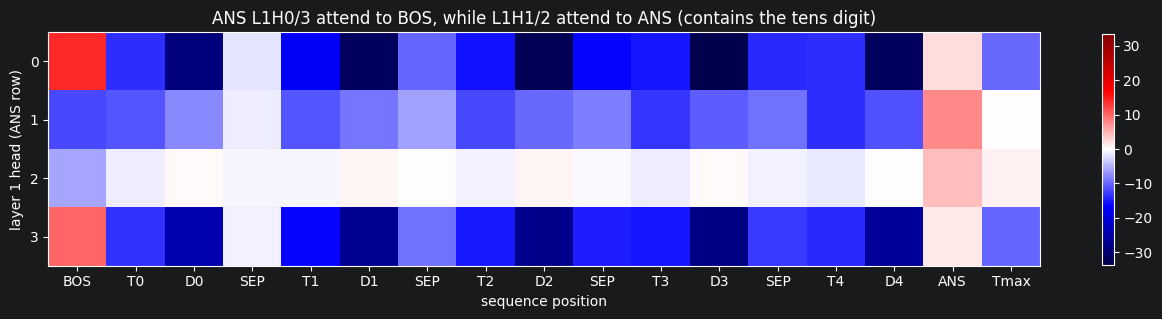

In [12]:
title = f'ANS L1H0/3 attend to BOS, while L1H1/2 attend to ANS (contains the tens digit)'
layer = 1; n_samples = 1000; pos = -2 # tens digit

attn_in_pos = model_2.attn_in[layer,:n_samples].mean(axis=0)  # Average attn_in over each position
ans1_attn_in = attn_in_pos[[pos]]

scores = np.stack([model_2.quick_attn(layer,head, rows=ans1_attn_in, cols=attn_in_pos, softmax=False) for head in range(model_2.n_heads)])
fig,axs = imshow(scores.reshape(4, -1), title=title, colorbar=True, colorbar_scale=0.5,
                 xticks=model_2.seq_labels[:-2], yticks=np.arange(model_2.n_heads), center=True,
                 xlabel='sequence position', ylabel=f'layer {layer} head (ANS row)', figsize=(16,6));

We determined earlier that ANS contains the max tens digit after layer 0. In layer 1, it appears heads either output constants (L1H0/3) or look back at the ANS position containing the tens digit (L1H1/2).

---
<a id="2-3"></a>
## 2-3. How is the max tens digit copied to ANS+1?

> "L0H0/2 (heads 0 and 2): Attend to the ANS row, which we know from above contains the tens digit. This info is copied to the ANS+1 residual row."

At ANS+1, we are predicting the ones digit. The tens digit has already been predicted at ANS.

Looking at the ANS+1 row of our attention matrix, we see that for heads 1&3, the ANS position is now attended to (dark red).
- Hence, these heads likely copy the max tens digit directly to the ANS+1 residual stream.
- Recall that at ANS, L0H1 directly determined the max digit! But now at ANS+1 it has changed function, now copying it from the ANS row.

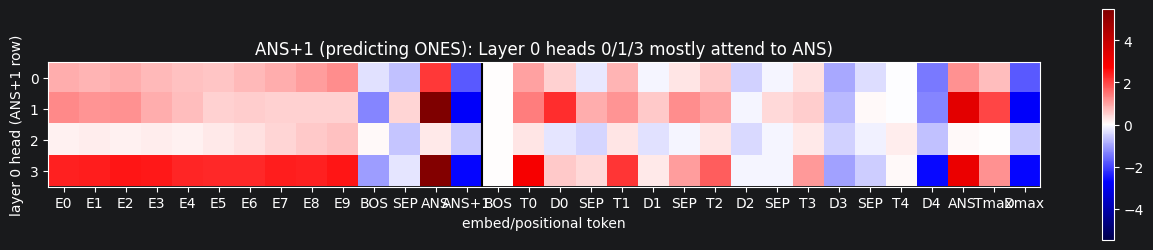

In [13]:
# Note these are raw attention scores, so highest attention probability on LARGEST present.
title = 'ANS+1 (predicting ONES): Layer 0 heads 0/1/3 mostly attend to ANS)'

tens_digit = 5  # Even changing the tens digit, ANS still has the largest score (dark red).
row = model_2.W_E[tens_digit] + model_2.W_P[model_2.ANS_POS+1]
show_attn_gradient(model_2, layer=0, title=title, sub_pos=model_2.ANS+2, row=row, ylabel='layer 0 head (ANS+1 row)')

Note this is weak evidence alone that information is copied! But recall in [2-1](#2-1) we showed that the output of these heads places the tens digit onto the residual stream.


---
<a id="2-4"></a>
# 2-4. How is each tens digit copied into the corresponding ones-digit activation row?

> "L0H3: Copies each tens digit into the corresponding ones-digit residual activation row."

After layer 0, the ones digit activation rows now contain information about the tens digits! As we will show, this allows layer 1 heads to mask ones digits based on their tens digit.

- Recall this is layer 0, so in this model `S[E + P] = S[E] + S[P]`.

This graph shows how each E/PE attends to each E/PE.
- On left, the embedding scores are small and ~equally attend to each other (to verify, set `softmax=False`).
- On right, each ones digit attends to its corresponding tens digit (e.g. D0 attends to T0, the darkest red squares)
- As above, note there is redundancy. Although this head clearly copies the tens digit, other heads copy it some as well (seen in the attn gradient above)!

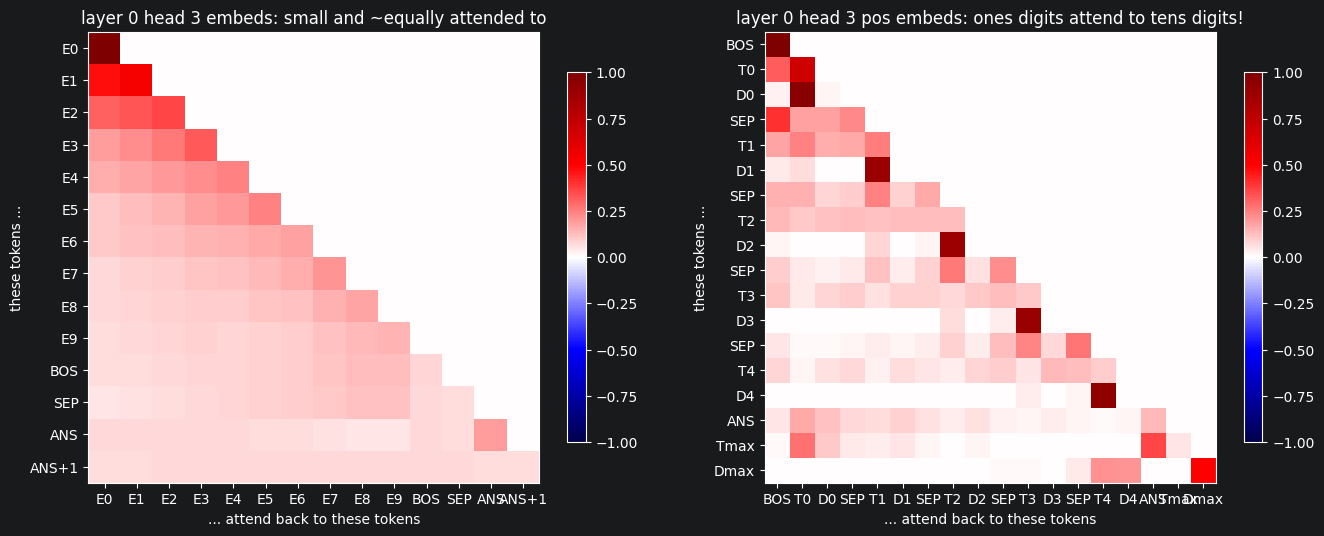

In [14]:
layer = 0; head = 3

# quick_attn creates an attention matrix with specified rows and cols for input residuals
scores = model_2.quick_attn(layer,head, rows=model_2.W_E,cols=model_2.W_E, softmax=True)
fig,axs = plt.subplots(1,2, figsize=(16,6))
imshow(scores, center=True, xlabel='... attend back to these tokens', ylabel='these tokens ...',
       xticks=model_2.embed_labels, yticks=model_2.embed_labels, axs=axs[0],
       title=f'layer {layer} head {head} embeds: small and ~equally attended to');

scores = model_2.quick_attn(layer,head, rows=model_2.W_P,cols=model_2.W_P, softmax=True)
imshow(scores, center=True, xlabel='... attend back to these tokens', ylabel='these tokens ...',
       xticks=model_2.seq_labels[:-1], yticks=model_2.seq_labels[:-1], axs=axs[1], colorbar=True,
       title=f'layer {layer} head {head} pos embeds: ones digits attend to tens digits!');

In [2-2](#2-2) we showed that L0H1 had a dual function. Here, we see that L0H3 does too! It attends to ANS at position ANS+1, but it attends to the max tens digit in position ANS.

---
<a id="2-5"></a>
## 2-5. Which layer 1 heads are responsible for outputting the max tens and ones digits?

> "Before layer 1, the max tens digit is already known and on the ANS-row residual stream. Using logit attribution, we show that layer 1 heads (A) reinforce this true class (especially heads 1&2) and (B) otherwise provide per-class constants to properly match the unembeddings."

This section performs an analysis of the per-head logit contributions.

For each head, we'll determine which classes it is "responsible" for predicting (for both ANS and ANS+1). In summary:
- L1H0: **[ANS]** Identifies 4-8.  **[ANS+1]** ~Same.
- L1H1: **[ANS]** Identifies 0-4.  **[ANS+1]** Outputs constants (i.e. no true-class signal).
- L1H2: **[ANS]** Identifies 9. **[ANS+1]** Outputs constants (with high variance).
- L1H3: **[ANS]** Identifies 8-9. **[ANS+1]** ~Same.

In [15]:
# For the ANS (tens digit), L1H0 identifies 5-8. L1H1: 0-4. L1H2: 9, L1H3: 8,9.
title = 'ANS L1H1 biases toward 0-4.\nL1H0 negates 0-2 when identifying 4-8, while L1H2 identifies 9 & L1H4: 7-9.'
means, stds = attn_logit_means(model_2, y_true_2, tens_digit=True)
fig = show_logit_contribs(model_2, means, stds, layer=1, title=title, xaxis_ytrue=False)

By comparing the last and next graphs, note how similar some of the heads are -- they actually output similar classes despite being for the tens and ones digits!
- We know the tens digit is on the stream in both cases, each time partially copied there by L0H1. So it may activate heads similarly.
- Recall from [2-1](#2-1) that L1H1/2 mostly output the tens digit. This may be why the ANS+1 graph below shows them outputting constants.
- Note that these conclusions are sometimes different from the logreg results in [2-1](#2-1) because these use the ACTUAL unembeddings, while 2-1 uses custom unembeddings per head.

Finally, we examine the ANS+1 layer 1 heads.
- Note it appears only true classes 5-9 are specifically identified. However, the heads still output true classes 0-4 because L1H1/2 are highly biased toward them. Notice that when these constants are large, L1H0/3 are ~zero.

In [16]:
# For ANS+1 (ones digit), L1H1/2 are constants while L1H3 identifies 8,9 and L1H0: 4-8.
title = 'ONES DIGIT Layer 1: Head 1&2 contribute ~constant per-class biases.\nHead 0 negates 0-2 when identifying 4-8, while head 3 identifies 8-9.'
means, stds = attn_logit_means(model_2, y_true_2, tens_digit=False)
fig = show_logit_contribs(model_2, means, stds, layer=1, title=title, xaxis_ytrue=False)

Recall this analysis uses means+stds -- it will miss any special cases which are used for a few inputs. However, we are lucky that many standard deviations are small, giving confidence for most heads that the conclusions generally hold.

Due to skip connections, the final logits are the sum of the head contributions from layers 0 and 1, plus the embeds.
- We omitted the layer 0 and embeds graphs here, because their logit contributions are minor in comparison. However, you can view them simply by changing the layer parameter above!

---
<a id="2-6"></a>
## 2-6. How are the ones digits matched with the max tens digit in layer 1?

> "L1H0/3: Recognize the max ones digit by applying: (A) a score boost when [(2-4)](#2-4) matches with [(2-3)](#2-3), (B) a score gradient to the ones digits themselves, and (C) a mask on the ones digits via the positional embeds."

And now for the grand finale! We show that:
- L1H0/3 match the tens digit information in the ANS+1 activations row (placed there via L0H1/3 @ANS+1) ...
- ... with the tens information stored in each ones digit activation row (placed there via L0H3 pre-ANS).
- Using these as a mask, it then applies a score gradient across the masked ones digits, placing the largest on the output residual stream!

As we did above, to determine the layer 1 positional effect we take the mean of each layer 1 attn_in (verifying this manually via attention patterns):
- For fun, set `pos=-2` -- this shows why these heads @ ANS can't detect ones digits.
- Notice the ONES DIGIT squares are darkest red now!

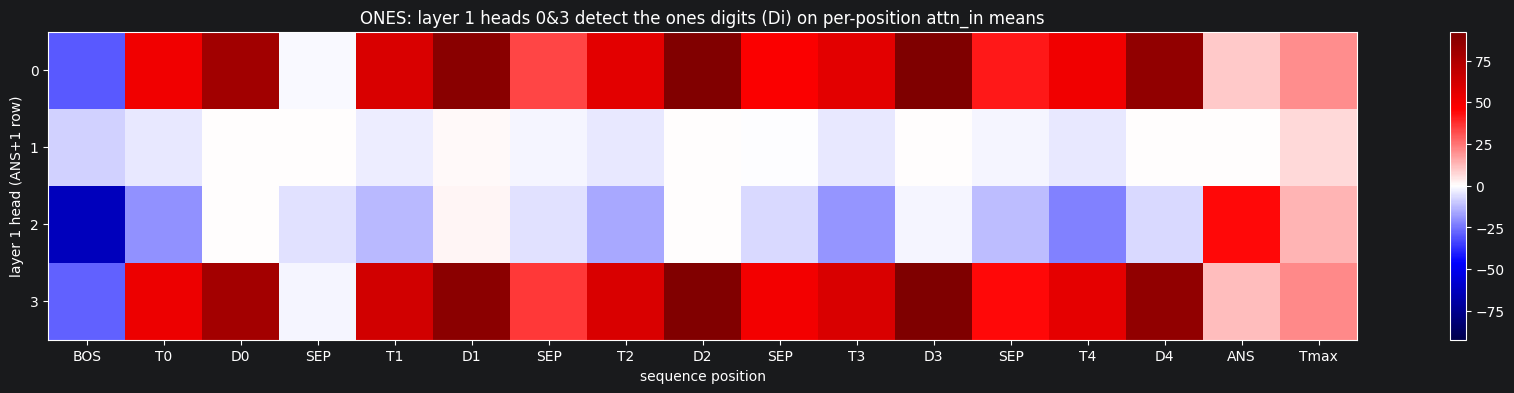

In [17]:
title = f'ONES: layer 1 heads 0&3 detect the ones digits (Di) on per-position attn_in means'
layer = 1; n_samples = 1000; pos = -1  # for fun, try this with ANS (pos=-2) -- this shows why ANS can't detect ones digits

attn_in_pos = model_2.attn_in[layer,:n_samples].mean(axis=0)  # Average attn_in over each position
ans1_attn_in = attn_in_pos[[pos]]

scores = np.stack([model_2.quick_attn(layer,head, rows=ans1_attn_in, cols=attn_in_pos, softmax=False) for head in range(model_2.n_heads)])
fig,axs = imshow(scores.reshape(4, -1), title=title, colorbar=True, colorbar_scale=1.0,
                 xticks=model_2.seq_labels[:-2], yticks=np.arange(model_2.n_heads), center=True,
                 xlabel='sequence position', ylabel=f'layer {layer} head (ANS+1 row)', figsize=(24,4));

The darkest red squares are now ones digits! We've shown:
- Heads 0&3 output complete knowledge of the max ones digit, and 1&2 do not (section [(2-1)](#2-1])).
- Heads 0&3 seem to attend most to the ones digit sequence positions.

All remaining is to show (1) a score gradient on the ones digits, and (2) an extra score boost is given to ones digits following the max ten.

Let's first observe the gradient on the ones digits. Each column `Ei` now represents the mean ones-digit attn_ins that follow the tens' digit `Ei`. As we predicted, there is an increasing score gradient.
- For example, `S[8|58] > S[2|32]`, because the tens digits 5 > 3. We show that on average this is true.

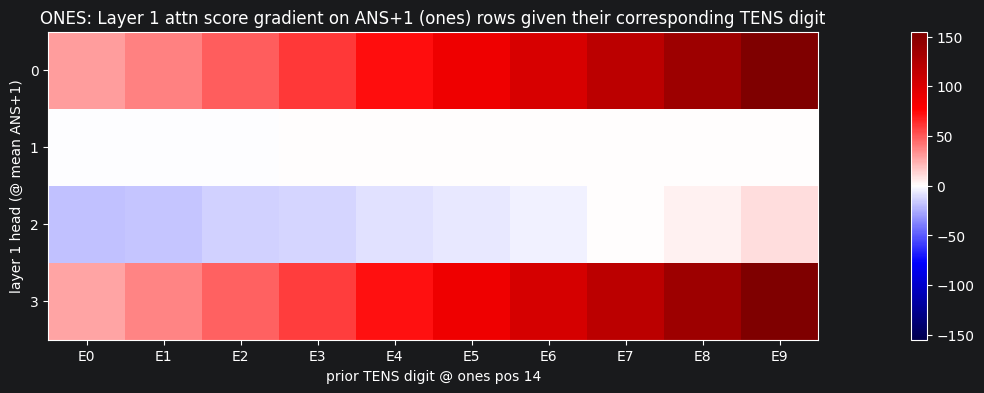

In [18]:
title = 'ONES: Layer 1 attn score gradient on ANS+1 (ones) rows given their corresponding TENS digit'
layer = 1; n_samples = 1000; pos = -1       # ANS+1
tens_seq_pos = np.array([1, 4, 7, 10, 13])  # positions of tens digits (for reference)
tens_pos = tens_seq_pos[4]                  # vary this to show the gradient applies to all positions!

# Average ANS+1 attn_ins based on their preceding TENS digit
ones_attn_in = mean_attn_in(model_2, layer, tens_pos+1, digit_ix_fn=lambda digit: where(seqs_2[:,tens_pos] == digit))

ans1_attn_in = model_2.attn_in[layer,:n_samples,pos].mean(axis=0)[None]  # Average attn_in over each position

scores = np.stack([model_2.quick_attn(layer,head, rows=ans1_attn_in, cols=ones_attn_in, softmax=False) for head in range(model_2.n_heads)])
fig,axs = imshow(scores.reshape(4, -1), title=title, colorbar=True, colorbar_scale=1.0,
                 xticks=model_2.embed_labels[:-4], yticks=np.arange(model_2.n_heads), center=True,
                 xlabel=f'prior TENS digit @ ones pos {tens_pos+1}', ylabel=f'layer {layer} head (@ mean ANS+1)', figsize=(24,4));

Now finally, we must show that a score boost is given to the ones digit corresponding to the max tens digit.

We show this happens on average. To interpret the heatmaps:
- The column `Ei` still represents the mean ones digit attn_ins, given a prior tens digit `Ei`.
- The row `j` is now the mean ANS+1 attn_in as before, but with true max ten `j`.

Note:
- The first row is likely 0 since our sample is unlikely to contain it.
- This may be better represented as a lower-left triangle, since in practice no column can exceed the max tens digit.

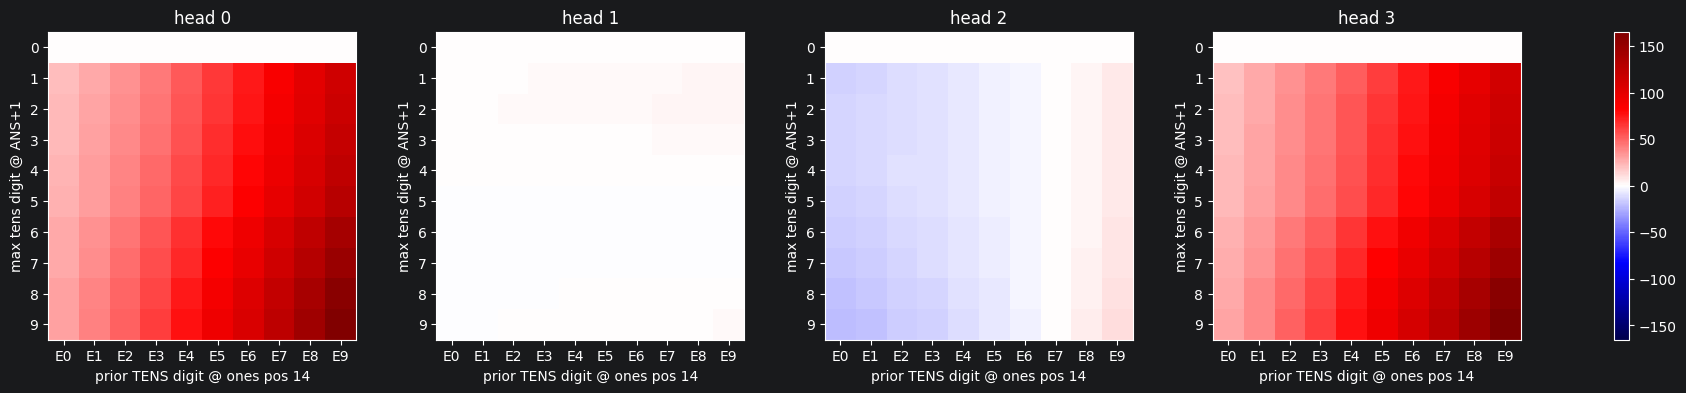

In [19]:
layer = 1; n_samples = 1000; pos = -1       # ANS+1
tens_seq_pos = np.array([1, 4, 7, 10, 13])  # positions of tens digits (for reference)
tens_pos = tens_seq_pos[4]                  # vary this to show the gradient applies to all positions!

# cols: Average ANS+1 attn_ins based on their preceding TENS digit
ones_attn_in = mean_attn_in(model_2, layer, tens_pos+1, digit_ix_fn=lambda digit: where(seqs_2[:,tens_pos] == digit))

# rows: Average attn_in at the ANS+1 position based on the ACTUAL max tens digit
ans1_attn_in = mean_attn_in(model_2, layer, pos, digit_ix_fn=lambda digit: where((y_true_2 // 10 == digit) & (seqs_2[:,tens_pos] == digit)))

scores2 = np.stack([model_2.quick_attn(layer,head, rows=ans1_attn_in, cols=ones_attn_in, softmax=False) for head in range(model_2.n_heads)])
fig,axs = imshow(scores2, facet_col=0, colorbar=True, colorbar_scale=1.0, title='head',
                 xticks=model_2.embed_labels[:-4], yticks=np.arange(model_2.n_digits), center=True,
                 xlabel=f'prior TENS digit @ ones pos {tens_pos+1}', ylabel=f'max tens digit @ ANS+1', figsize=(24,4));

This visually shows the score boost given when the actual tens digit in the ones position matches the max tens digit @ ANS+1! Note that "nearby" digits also get substantial boosts.

Note the above analysis is not causal. It relies on mean-class vectors which may be coincidental or not representative of many cases! However, we've shown heads 0&3 are responsible for max ones digit output in numerous ways, e.g. by logit contributions, logistic regression analysis, and head ablations (appendix 1).

**In conclusion:** We thoroughly provided multiple pieces of evidence for each step of the proposed mechanism. In this case, we could fairly succinctly describe the contribution of each head. However, in some cases heads did perform multiple functions which complicates understanding. New techniques may be needed to understand transformers with >2 layers, since they will no longer be directly connected to an interpretable embedding/unembedding.

---
<a id="3-1"></a>
## Appendix 1: Head ablation experiment

Here, we verify some of the results above by ablating heads. Note this is often difficult to interpret, because as heads become ablated the model relies on other biases which may actually INCREASE the accuracy due to class imbalance.
- For example, when all puzzle 2 layer 0 heads are ablated, it gets 43% accuracy by simply guessing the most-common maxes!
- Also note that many heads contribute per-class logit biases. Ablating these alone may cause a large accuracy disruption.

Interesting things to try that we concluded above (note the %s depend on the random sample):
- Puzzle 1: L0H3 is required to accurately detect classes 0-6, and ablating heads 1&3 reduces accuracy to ~9%.
- Puzzle 2: TENS - Ablating L0H1 (which detects the tens digit) reduces the tens-digit accuracy to ~16%, still higher than chance!
- Puzzle 2: ONES - Ablating L0H0/2 (which copy the ANS row) still gets ~59% accuracy, possibly because ANS is also copied by other heads but less prominently.
- Puzzle 2: ONES - Ablating L0H3 (which copies the tens to the ones) along with head 2 reduces accuracy to ~9%
- Puzzle 2: ONES - L1H0/3 are required to accurately detect the ones digit (reducing it to ~9% just by ablating 3).
- Puzzle 2: TENS - L1H1/2 (and somewhat 3) output the tens digit (ablating 1&2/1&3 reduces tens accuracy to ~9%/2%).

In [20]:
# ABLATION EXPERIMENT - ablating layer 0 head 3 results in layer 1 heads 0/3 not detecting the ones
# WARNING: These experiments overwrite stored activations. So you must re-run code at the top that runs 100,000 samples.
from collections import Counter

def all_ablations(model, seqs, head_subsets, ablate_layer):
    preds = np.empty((len(seqs), len(head_subsets)), dtype=int)
    for headi,head_ixs in enumerate(head_subsets):
        ablated_logits = model.run_ablate_head(seqs, ablate_layer, head_ixs)
        preds[:,headi] = np.argmax(ablated_logits[:,-1], axis=-1)
    return preds

head_subsets = [  # Empty set must be first for accuracy comparison!
    [], [0], [1], [2], [3],
    [0,1], [0,2], [0,3], [1,2], [1,3], [2,3],
    [0,1,2], [0,1,3], [0,2,3], [1,2,3], [0,1,2,3]
]

In [21]:
# ONES_POS = True is the ones digit / False is the tens digit
PUZZLE_1 = True; ONES_POS = True; n_seqs = 1000; ablate_layer = 0

m = model_1 if PUZZLE_1 else model_2; layer = 0 if PUZZLE_1 else layer
use_seqs = seqs_1[:n_seqs] if PUZZLE_1 else (seqs_2[:n_seqs] if ONES_POS else base_seqs_2[:n_seqs])

preds = all_ablations(m, use_seqs, head_subsets, ablate_layer=ablate_layer)
for headi, head_ix in enumerate(head_subsets):
    print(f'{np.mean(preds[:,headi] == preds[:,0]):.2f}', head_ix, Counter(preds[:,headi]))

1.00 [] Counter({np.int64(9): 271, np.int64(8): 217, np.int64(7): 169, np.int64(6): 127, np.int64(5): 91, np.int64(4): 61, np.int64(3): 37, np.int64(2): 19, np.int64(1): 7, np.int64(0): 1})
0.40 [0] Counter({np.int64(8): 657, np.int64(6): 218, np.int64(5): 61, np.int64(3): 37, np.int64(2): 19, np.int64(0): 8})
1.00 [1] Counter({np.int64(9): 271, np.int64(8): 217, np.int64(7): 169, np.int64(6): 127, np.int64(5): 91, np.int64(4): 61, np.int64(3): 37, np.int64(2): 19, np.int64(1): 5, np.int64(0): 3})
0.54 [2] Counter({np.int64(6): 398, np.int64(8): 308, np.int64(7): 267, np.int64(2): 19, np.int64(0): 4, np.int64(1): 4})
0.29 [3] Counter({np.int64(2): 343, np.int64(9): 271, np.int64(7): 218, np.int64(3): 168})
0.40 [0, 1] Counter({np.int64(9): 657, np.int64(6): 279, np.int64(4): 34, np.int64(1): 19, np.int64(0): 8, np.int64(3): 3})
0.15 [0, 2] Counter({np.int64(6): 806, np.int64(8): 167, np.int64(2): 19, np.int64(0): 8})
0.46 [0, 3] Counter({np.int64(9): 488, np.int64(2): 343, np.int64(7):

---
<a id="3-2"></a>
## Appendix 2: Attention Explorer

nums: [85 91 15 52 39]
 seq: [10  8  5 11  9  1 11  1  5 11  5  2 11  3  9 12  9]


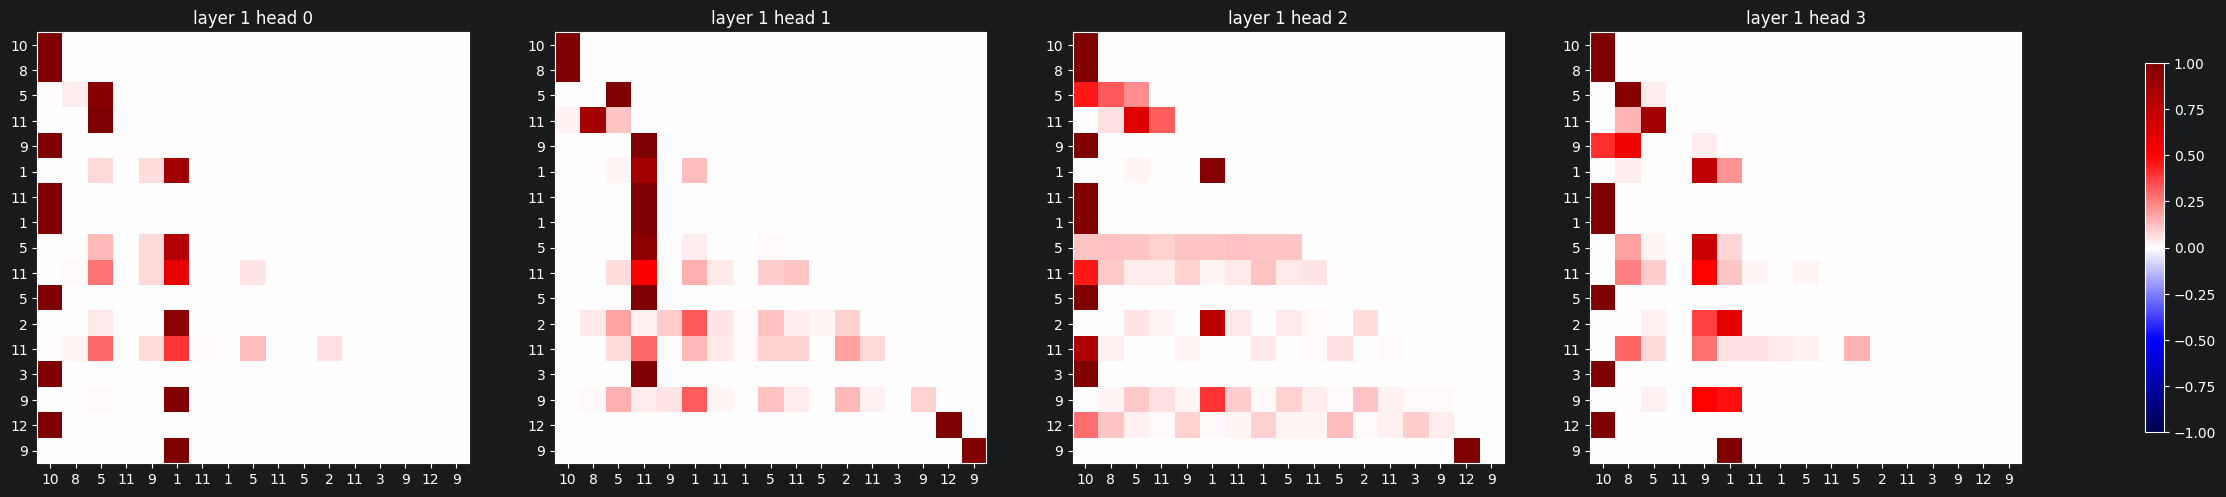

In [22]:
# Note: In Puzzle 2, the last row is the first max tens digit!
PUZZLE_1 = False; SHOW_SCORES = False
layer = 1; head = 0
example_ix = 0

m = model_1 if PUZZLE_1 else model_2; acts = m.scores if SHOW_SCORES else m.pattern
use_seqs = seqs_1 if PUZZLE_1 else seqs_2
print('nums:', nums_1[example_ix] if PUZZLE_1 else nums_2[example_ix])
print(' seq:', use_seqs[example_ix])

#example_ix = where(use_seqs[:,-1] == 1)[0]                             # select a specific digit
#example_ix = where((use_seqs[:,-2] == 1) & (use_seqs[:,-1] == 1))[0]   # select a specific tens+ones digit

n_toks = len(use_seqs[example_ix])
imshow(acts[layer,example_ix,:, :n_toks,:n_toks], facet_col=0, center=True, title=f'layer {layer} head',
       xticks=use_seqs[example_ix], yticks=use_seqs[example_ix], figsize=(32,6));